In [1]:
import pandas as pd
import numpy as np

In [2]:
data = pd.DataFrame({
    "Department": ["CSE", "ECE", "ME", "CE", "EEE"],
    "Students_2022": [120, 100, 80, 70, 60],
    "Students_2023": [140, 110, 90, 65, 75]
})


In [3]:
scores = pd.DataFrame({
    "Marks": np.random.normal(70, 10, 200)
})


In [4]:
scores_multi = pd.DataFrame({
    "Group": np.repeat(["A", "B"], 200),
    "Marks": np.hstack([
        np.random.normal(65, 8, 200),
        np.random.normal(75, 10, 200)
    ])
})


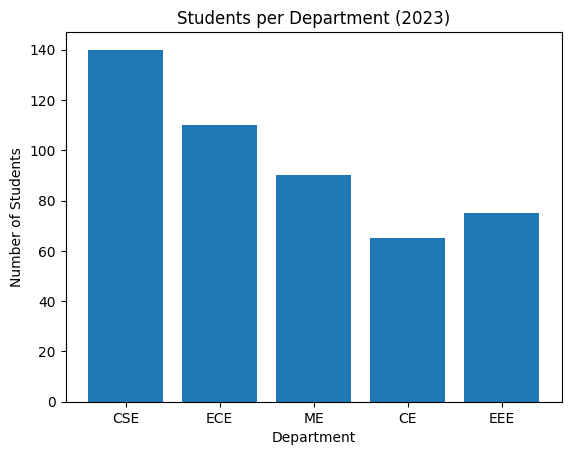

In [6]:
import matplotlib.pyplot as plt
plt.bar(data["Department"], data["Students_2023"])
plt.xlabel("Department")
plt.ylabel("Number of Students")
plt.title("Students per Department (2023)")
plt.show()


<function matplotlib.pyplot.ylabel(ylabel: 'str', fontdict: 'dict[str, Any] | None' = None, labelpad: 'float | None' = None, *, loc: "Literal['bottom', 'center', 'top'] | None" = None, **kwargs) -> 'Text'>

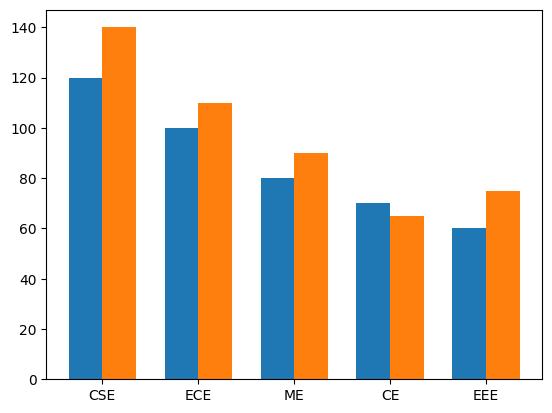

In [7]:
x = np.arange(len(data["Department"]))
width = 0.35

plt.bar(x - width/2, data["Students_2022"], width, label="2022")
plt.bar(x + width/2, data["Students_2023"], width, label="2023")

plt.xticks(x, data["Department"])
plt.ylabel


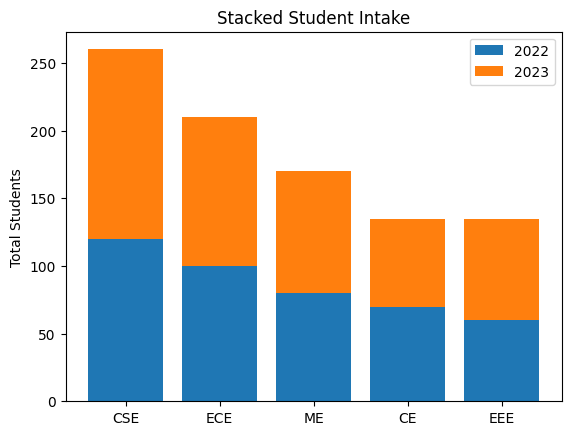

In [18]:
plt.bar(data["Department"], data["Students_2022"], label="2022")
plt.bar(data["Department"], data["Students_2023"],bottom=data["Students_2022"], label="2023")
plt.ylabel("Total Students")
plt.title("Stacked Student Intake")
plt.legend()
plt.show()


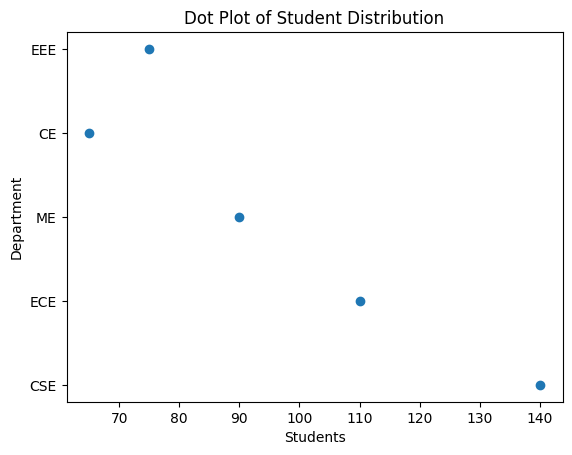

In [10]:
plt.plot(data["Students_2023"], data["Department"], "o")
plt.xlabel("Students")
plt.ylabel("Department")
plt.title("Dot Plot of Student Distribution")
plt.show()


In [31]:
import seaborn as sns
sns.heatmap(data.set_index("Department"),
            annot=True, cmap="reds")
plt.title("Heatmap of Student Data")
plt.show()


KeyError: "'reds' is not a known colormap name"

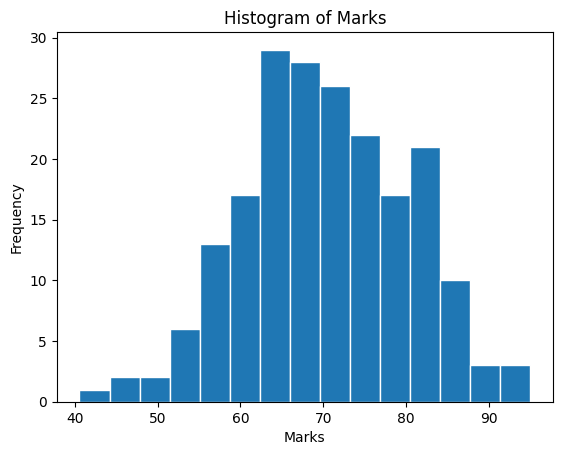

In [28]:
plt.hist(scores["Marks"], bins=15, edgecolor="white")
plt.xlabel("Marks")
plt.ylabel("Frequency")
plt.title("Histogram of Marks")
plt.show()


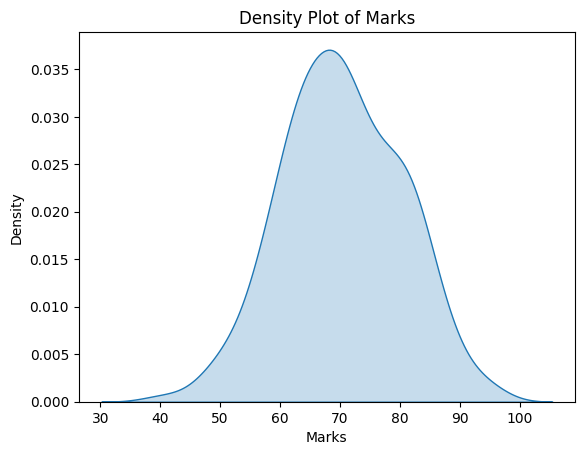

In [14]:
sns.kdeplot(scores["Marks"], fill=True)
plt.title("Density Plot of Marks")
plt.xlabel("Marks")
plt.show()


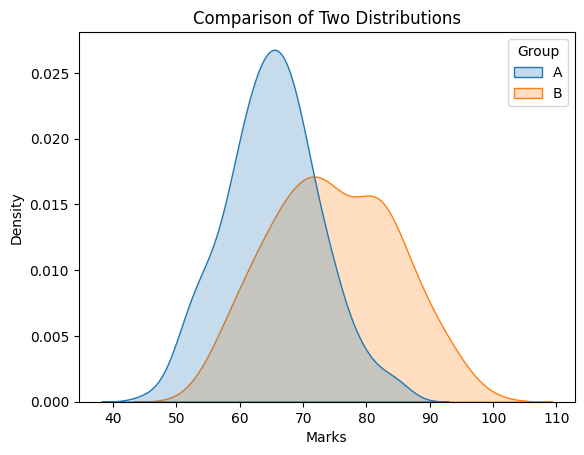

In [15]:
sns.kdeplot(data=scores_multi,
            x="Marks", hue="Group",
            fill=True)
plt.title("Comparison of Two Distributions")
plt.show()


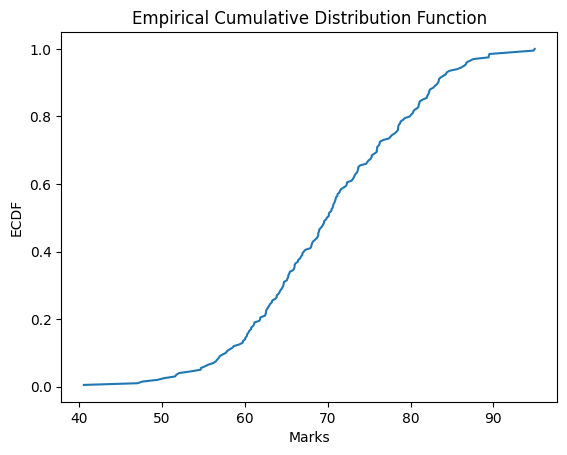

In [16]:
x = np.sort(scores["Marks"])
y = np.arange(1, len(x)+1) / len(x)
plt.plot(x, y)
plt.xlabel("Marks")
plt.ylabel("ECDF")
plt.title("Empirical Cumulative Distribution Function")
plt.show()


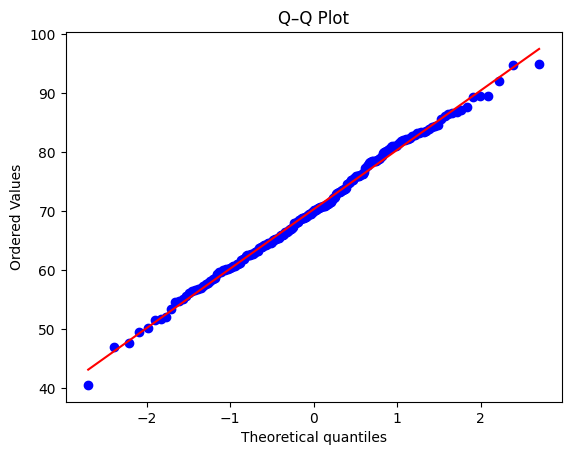

In [17]:
import scipy.stats as stats

stats.probplot(scores["Marks"], plot=plt)
plt.title("Q–Q Plot")
plt.show()


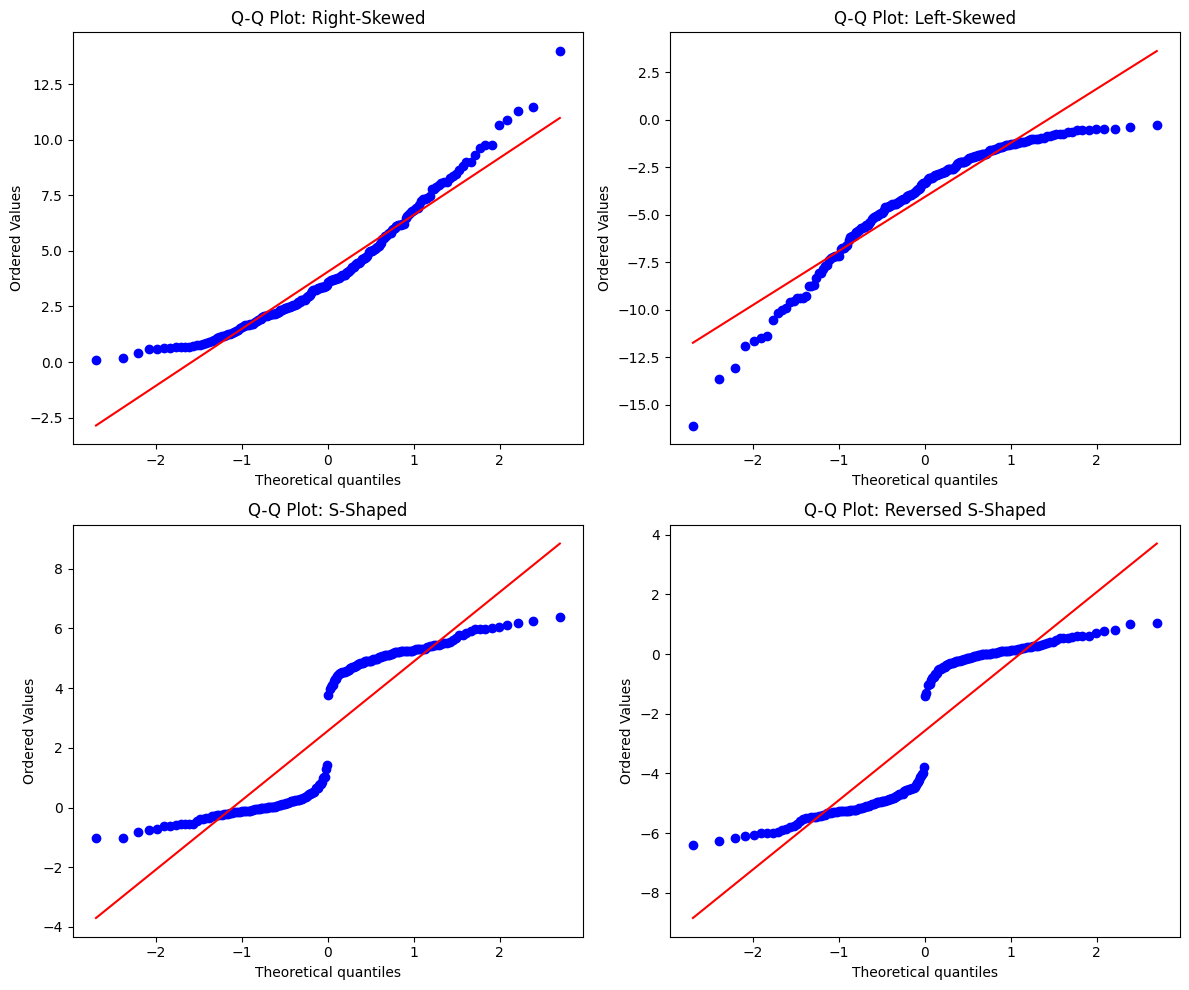

In [29]:
# Q-Q Plot for different distributions
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Right-skewed distribution
right_skewed = np.random.gamma(2, 2, 200)
stats.probplot(right_skewed, dist="norm", plot=axes[0, 0])
axes[0, 0].set_title("Q-Q Plot: Right-Skewed")

# Left-skewed distribution
left_skewed = -np.random.gamma(2, 2, 200)
stats.probplot(left_skewed, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title("Q-Q Plot: Left-Skewed")

# S-shaped distribution
s_shaped = np.concatenate([np.random.normal(0, 0.5, 100), np.random.normal(5, 0.5, 100)])
stats.probplot(s_shaped, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title("Q-Q Plot: S-Shaped")

# Reversed S-shaped distribution
reversed_s = -s_shaped
stats.probplot(reversed_s, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title("Q-Q Plot: Reversed S-Shaped")

plt.tight_layout()
plt.show()